In [1]:
# Necessary Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from pandas.errors import OutOfBoundsDatetime
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')


Processing 60 sheets...
Sheets: ['Nom $ apprec method a)12 months', 'Nom $ apprec method b)12 months', 'Nom $ apprec method c)12 months', 'Nom $ apprec method d)12 months', 'Nom $ apprec method e)12 months', 'Nom $ aprrec method a)18 months', 'Nom $ apprec method b)18 months', 'Nom $ apprec method c)18 months', 'Nom $ apprec method d)18 months', 'Nom apprec $ method e)18 months', 'RPPP $ a) 12 months', 'RPPP $ b) 12 months', 'RPPP $ c) 12 months', 'RPPP $ d) 12 months', 'RPPP $ e) 12 months', 'RPPP $ a) 18 months', 'RPPP $ b) 18 months', 'RPPP $ c) 18 months', 'RPPP $ d) 18 months', 'RPPP $ e) 18 months', 'RPPP ¥ a) 12 months ', 'RPPP ¥ b) 12 months', 'RPPP ¥ c) 12 months', 'RPPP ¥ d) 12 months', 'RPPP ¥ e) 12 months', 'RPPP ¥ a) 18 months', 'RPPP ¥ b) 18 months', 'RPPP ¥ c) 18 months', 'RPPP ¥ d) 18 months', 'RPPP ¥ e) 18 months', 'IFE $ a) 12 months', 'IFE $ b) 12 months', 'IFE $ c) 12 months', 'IFE ¥ a) 12 months', 'IFE ¥ b) 12 months', 'IFE ¥ c) 12 months', 'IFE $ a) 18 months', '

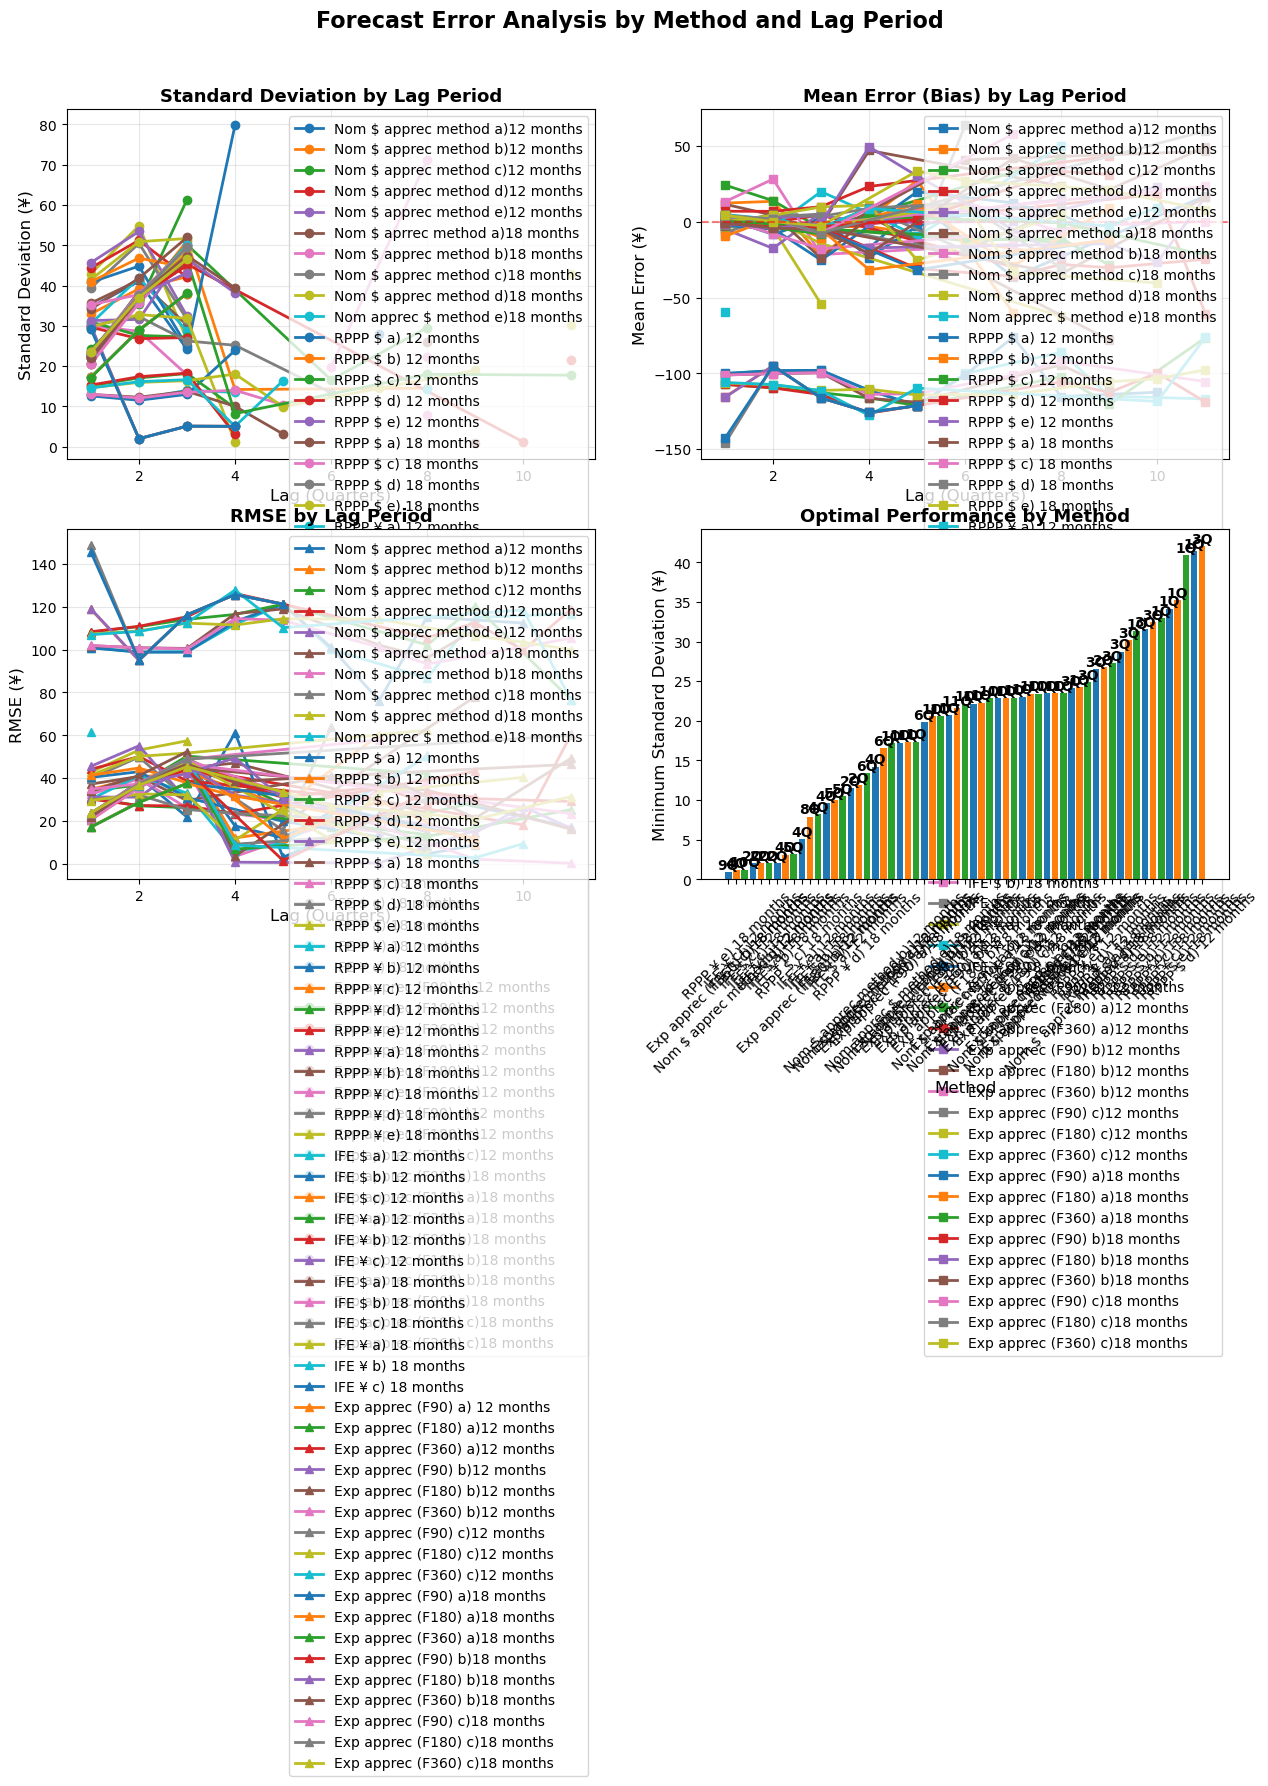

Saved: forex_analysis_all_methods.csv
Saved: forex_analysis_optimal_lags.csv
Saved: forex_analysis_Nom_$_apprec_method_a)12_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_b)12_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_c)12_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_d)12_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_e)12_months_detailed.csv
Saved: forex_analysis_Nom_$_aprrec_method_a)18_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_b)18_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_c)18_months_detailed.csv
Saved: forex_analysis_Nom_$_apprec_method_d)18_months_detailed.csv
Saved: forex_analysis_Nom_apprec_$_method_e)18_months_detailed.csv
Saved: forex_analysis_RPPP_$_a)_12_months_detailed.csv
Saved: forex_analysis_RPPP_$_b)_12_months_detailed.csv
Saved: forex_analysis_RPPP_$_c)_12_months_detailed.csv
Saved: forex_analysis_RPPP_$_d)_12_months_detailed.csv
Saved: forex_analysis_RPPP_$_e)_1

In [3]:
# Multi-Method ForEx Prediction Analyzer
class ForexPredictionAnalyzer:
    """
    Comprehensive analyzer for multiple forex prediction methods.
    Handles multiple sheets, calculates errors, and finds optimal lag periods.
    """
    
    def __init__(self, file_path: str):
        """
        Initialize analyzer with Excel file.
        
        Parameters:
        -----------
        file_path : str
            Path to Excel file containing prediction sheets
        """
        self.file_path = "Project Japan 202 backtesting.xls"
        self.sheet_data = {}
        self.results = {}
        self.comparison_df = None
        
    def get_sheet_names(self) -> List[str]:
        """Get all sheet names except first and last two."""
        xl_file = pd.ExcelFile(self.file_path)
        all_sheets = xl_file.sheet_names
        
        # Exclude first and last two sheets
        if len(all_sheets) > 3:
            return all_sheets[1:-2]
        else:
            print("Warning: Not enough sheets. Using all sheets.")
            return all_sheets
    
    def parse_sheet(self, sheet_name: str) -> pd.DataFrame:
        """
        Parse a single sheet with prediction data.
        
        Parameters:
        -----------
        sheet_name : str
            Name of the sheet to parse
            
        Returns:
        --------
        pd.DataFrame
            Parsed data with columns: Date, Actual_Spot, Lag_Quarters, Predicted_Spot
        """
        print(f"Parsing sheet: {sheet_name}")
        
        # Read the sheet
        df = pd.read_excel(self.file_path, sheet_name=sheet_name, header=None)
        
        # Initialize lists
        dates = []
        actual_spots = []
        lag_quarters = []
        predicted_spots = []
        
        # Parse data
        for idx, row in df.iterrows():
            date_val = row[0]
            spot_val = row[1]
            
            # Skip invalid dates/spots
            if pd.isna(date_val) or not isinstance(date_val, (datetime, pd.Timestamp, str)):
                continue
            if pd.isna(spot_val):
                continue
                
            try:
                spot_val = float(spot_val)
            except (ValueError, TypeError):
                continue
            
            # Look for N/360 and E(S¥/$N) pairs
            for col_idx in range(2, len(row)):
                cell_val = row[col_idx]
                
                if pd.notna(cell_val):
                    try:
                        n_val = float(cell_val)
                        
                        # Only accept lag values 1-12 quarters
                        if 1 <= n_val <= 12:
                            # Look for predicted spot rate in next few columns
                            for offset in range(1, 4):
                                if col_idx + offset < len(row):
                                    pred_val = row[col_idx + offset]
                                    if pd.notna(pred_val):
                                        try:
                                            pred_spot = float(pred_val)
                                            # Reasonable spot rate range
                                            if 50 <= pred_spot <= 200:
                                                dates.append(date_val)
                                                actual_spots.append(spot_val)
                                                lag_quarters.append(int(n_val))
                                                predicted_spots.append(pred_spot)
                                                break
                                        except (ValueError, TypeError):
                                            continue
                    except (ValueError, TypeError):
                        continue
        
        # Create DataFrame
        result_df = pd.DataFrame({
            'Date': dates,
            'Actual_Spot': actual_spots,
            'Lag_Quarters': lag_quarters,
            'Predicted_Spot': predicted_spots
        })
        
        # Remove duplicates and sort
        result_df = result_df.drop_duplicates()
        result_df = result_df.sort_values(['Date', 'Lag_Quarters'])
        
        print(f"  Found {len(result_df)} predictions")
        print(f"  Lag quarters: {sorted(result_df['Lag_Quarters'].unique())}")
        
        return result_df
    
    def calculate_forecast_errors(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate forecast errors for predictions.
        
        Parameters:
        -----------
        df : pd.DataFrame
            DataFrame with Date, Actual_Spot, Lag_Quarters, Predicted_Spot
            
        Returns:
        --------
        pd.DataFrame
            Data with added forecast errors
        """
        # Ensure Date is datetime
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        # Create spot rate mapping
        spot_rate_map = dict(zip(df['Date'], df['Actual_Spot']))
        
        future_dates = []
        future_spots = []
        forecast_errors = []
        
        for _, row in df.iterrows():
            # Validate lag
            if not (1 <= row['Lag_Quarters'] <= 12):
                continue
                
            try:
                # Calculate future date
                future_date = row['Date'] + pd.DateOffset(months=int(row['Lag_Quarters']) * 3)
                
                # Get actual future spot rate
                if future_date in spot_rate_map:
                    future_spot = spot_rate_map[future_date]
                    error = future_spot - row['Predicted_Spot']
                else:
                    future_spot = np.nan
                    error = np.nan
                
                future_dates.append(future_date)
                future_spots.append(future_spot)
                forecast_errors.append(error)
                
            except (OutOfBoundsDatetime, OverflowError):
                continue
        
        # Add to DataFrame
        df['Future_Date'] = future_dates
        df['Future_Spot'] = future_spots
        df['Forecast_Error'] = forecast_errors
        
        # Remove rows without future data
        df = df.dropna(subset=['Forecast_Error'])
        
        return df
    
    def analyze_by_lag(self, df: pd.DataFrame, method_name: str) -> pd.DataFrame:
        """
        Calculate statistics for each lag period.
        
        Parameters:
        -----------
        df : pd.DataFrame
            DataFrame with Forecast_Error column
        method_name : str
            Name of the prediction method
            
        Returns:
        --------
        pd.DataFrame
            Summary statistics by lag
        """
        summary = df.groupby('Lag_Quarters').agg({
            'Forecast_Error': [
                'count',
                'mean',
                'std',
                lambda x: np.sqrt(np.mean(x**2))  # RMSE
            ]
        }).round(4)
        
        summary.columns = ['Count', 'Mean_Error', 'Std_Dev', 'RMSE']
        summary = summary.reset_index()
        summary['Method'] = method_name
        
        return summary
    
    def process_all_sheets(self):
        """Process all relevant sheets in the Excel file."""
        sheet_names = self.get_sheet_names()
        
        print(f"\nProcessing {len(sheet_names)} sheets...")
        print(f"Sheets: {sheet_names}\n")
        
        for sheet_name in sheet_names:
            try:
                # Parse sheet
                df = self.parse_sheet(sheet_name)
                
                if len(df) == 0:
                    print(f"  Warning: No data found in {sheet_name}\n")
                    continue
                
                # Calculate errors
                df_errors = self.calculate_forecast_errors(df)
                
                if len(df_errors) == 0:
                    print(f"  Warning: No calculable errors in {sheet_name}\n")
                    continue
                
                # Analyze by lag
                summary = self.analyze_by_lag(df_errors, sheet_name)
                
                # Store results
                self.sheet_data[sheet_name] = df_errors
                self.results[sheet_name] = summary
                
                print(f"  ✓ Processed {len(df_errors)} predictions with errors\n")
                
            except Exception as e:
                print(f"  ✗ Error processing {sheet_name}: {str(e)}\n")
                continue
    
    def compare_methods(self) -> pd.DataFrame:
        """
        Compare all methods and find optimal lag for each.
        
        Returns:
        --------
        pd.DataFrame
            Comparison of all methods across all lags
        """
        if not self.results:
            raise ValueError("No results to compare. Run process_all_sheets() first.")
        
        # Combine all results
        all_results = pd.concat(self.results.values(), ignore_index=True)
        self.comparison_df = all_results
        
        return all_results
    
    def get_optimal_lags(self) -> pd.DataFrame:
        """
        Find optimal lag for each method based on minimum standard deviation.
        
        Returns:
        --------
        pd.DataFrame
            Optimal lag and statistics for each method
        """
        if self.comparison_df is None:
            self.compare_methods()
        
        # Find minimum std dev for each method
        optimal = self.comparison_df.loc[
            self.comparison_df.groupby('Method')['Std_Dev'].idxmin()
        ]
        
        return optimal[['Method', 'Lag_Quarters', 'Std_Dev', 'Mean_Error', 'RMSE', 'Count']].sort_values('Std_Dev')
    
    def grid_search_optimal_lag(self, lag_range: Tuple[int, int] = (1, 12)) -> Dict:
        """
        Perform grid search to find optimal lag for each method.
        
        Parameters:
        -----------
        lag_range : Tuple[int, int]
            Range of lags to search (inclusive)
            
        Returns:
        --------
        Dict
            Results for each method with optimal lag
        """
        print(f"\nGrid Search: Testing lags {lag_range[0]} to {lag_range[1]} quarters\n")
        
        grid_results = {}
        
        for method_name, summary in self.results.items():
            # Filter to lag range
            filtered = summary[
                (summary['Lag_Quarters'] >= lag_range[0]) & 
                (summary['Lag_Quarters'] <= lag_range[1])
            ]
            
            if len(filtered) == 0:
                print(f"{method_name}: No data in lag range")
                continue
            
            # Find minimum std dev
            optimal_row = filtered.loc[filtered['Std_Dev'].idxmin()]
            
            grid_results[method_name] = {
                'Optimal_Lag': int(optimal_row['Lag_Quarters']),
                'Std_Dev': float(optimal_row['Std_Dev']),
                'Mean_Error': float(optimal_row['Mean_Error']),
                'RMSE': float(optimal_row['RMSE']),
                'Count': int(optimal_row['Count'])
            }
            
            print(f"{method_name}:")
            print(f"  Optimal Lag: {grid_results[method_name]['Optimal_Lag']} quarters")
            print(f"  Std Dev: {grid_results[method_name]['Std_Dev']:.4f}")
            print(f"  Mean Error: {grid_results[method_name]['Mean_Error']:.4f}")
            print(f"  RMSE: {grid_results[method_name]['RMSE']:.4f}\n")
        
        return grid_results
    
    def plot_comparison(self, save_path: str = None):
        """
        Create visualization comparing all methods across lags.
        
        Parameters:
        -----------
        save_path : str, optional
            Path to save the plot
        """
        if self.comparison_df is None:
            self.compare_methods()
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Forecast Error Analysis by Method and Lag Period', fontsize=16, fontweight='bold')
        
        # 1. Standard Deviation
        ax1 = axes[0, 0]
        for method in self.comparison_df['Method'].unique():
            data = self.comparison_df[self.comparison_df['Method'] == method]
            ax1.plot(data['Lag_Quarters'], data['Std_Dev'], marker='o', label=method, linewidth=2)
        ax1.set_xlabel('Lag (Quarters)', fontsize=12)
        ax1.set_ylabel('Standard Deviation (¥)', fontsize=12)
        ax1.set_title('Standard Deviation by Lag Period', fontsize=13, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Mean Error (Bias)
        ax2 = axes[0, 1]
        for method in self.comparison_df['Method'].unique():
            data = self.comparison_df[self.comparison_df['Method'] == method]
            ax2.plot(data['Lag_Quarters'], data['Mean_Error'], marker='s', label=method, linewidth=2)
        ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Lag (Quarters)', fontsize=12)
        ax2.set_ylabel('Mean Error (¥)', fontsize=12)
        ax2.set_title('Mean Error (Bias) by Lag Period', fontsize=13, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. RMSE
        ax3 = axes[1, 0]
        for method in self.comparison_df['Method'].unique():
            data = self.comparison_df[self.comparison_df['Method'] == method]
            ax3.plot(data['Lag_Quarters'], data['RMSE'], marker='^', label=method, linewidth=2)
        ax3.set_xlabel('Lag (Quarters)', fontsize=12)
        ax3.set_ylabel('RMSE (¥)', fontsize=12)
        ax3.set_title('RMSE by Lag Period', fontsize=13, fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # 4. Bar chart of optimal lags
        ax4 = axes[1, 1]
        optimal = self.get_optimal_lags()
        bars = ax4.bar(optimal['Method'], optimal['Std_Dev'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax4.set_xlabel('Method', fontsize=12)
        ax4.set_ylabel('Minimum Standard Deviation (¥)', fontsize=12)
        ax4.set_title('Optimal Performance by Method', fontsize=13, fontweight='bold')
        ax4.tick_params(axis='x', rotation=45)
        
        # Add lag labels on bars
        for bar, lag in zip(bars, optimal['Lag_Quarters']):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(lag)}Q',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to {save_path}")
        
        plt.show()
    
    def export_results(self, output_prefix: str = "forecast_analysis"):
        """
        Export all results to CSV files.
        
        Parameters:
        -----------
        output_prefix : str
            Prefix for output filenames
        """
        # Export comparison
        if self.comparison_df is not None:
            self.comparison_df.to_csv(f"{output_prefix}_all_methods.csv", index=False)
            print(f"Saved: {output_prefix}_all_methods.csv")
        
        # Export optimal lags
        optimal = self.get_optimal_lags()
        optimal.to_csv(f"{output_prefix}_optimal_lags.csv", index=False)
        print(f"Saved: {output_prefix}_optimal_lags.csv")
        
        # Export detailed results for each method
        for method_name, df in self.sheet_data.items():
            safe_name = method_name.replace(' ', '_').replace('/', '_')
            df.to_csv(f"{output_prefix}_{safe_name}_detailed.csv", index=False)
            print(f"Saved: {output_prefix}_{safe_name}_detailed.csv")


# Example usage
if __name__ == "__main__":
    # Initialize analyzer
    file_path = "Project Japan 202 backtesting.xls"
    analyzer = ForexPredictionAnalyzer(file_path)
    
    # Process all sheets
    analyzer.process_all_sheets()
    
    # Compare methods
    print("\n" + "="*60)
    print("COMPARISON OF ALL METHODS")
    print("="*60)
    comparison = analyzer.compare_methods()
    print(comparison.to_string())
    
    # Find optimal lags
    print("\n" + "="*60)
    print("OPTIMAL LAG FOR EACH METHOD")
    print("="*60)
    optimal = analyzer.get_optimal_lags()
    print(optimal.to_string())
    
    # Grid search (optional refinement)
    print("\n" + "="*60)
    print("GRID SEARCH RESULTS")
    print("="*60)
    grid_results = analyzer.grid_search_optimal_lag(lag_range=(1, 12))
    
    # Create visualizations
    analyzer.plot_comparison(save_path="forecast_comparison.png")
    
    # Export all results
    analyzer.export_results(output_prefix="forex_analysis")
    
    print("\n✓ Analysis complete!")